# Notebook 6 — Monte Carlo Simulation & Sensitivity Analysis

A single dispatch is just **one realization** of random fuel prices, wind, solar, and load noise. To draw policy conclusions, we need **statistical confidence** from many runs.

Topics:
1. Why Monte Carlo — what varies across runs
2. `run_monte_carlo()` — the core simulation loop
3. `sweep_technology()` — sensitivity to technology penetration
4. `build_sensitivity_heatmap()` — 2D analysis (tech × gas scenario)
5. `build_incremental_heatmap()` — marginal value and diminishing returns

**Runtime**: ~60 seconds (reduced MC runs for interactivity)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from energy_sim.config import ITALIAN_MIX, GAS_SCENARIOS
from energy_sim.simulation import (
    run_monte_carlo, sweep_technology, build_sensitivity_heatmap,
    build_incremental_heatmap,
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Why Monte Carlo?

Each MC run generates **fresh stochastic paths** for:
- Gas price (O-U process)
- Coal price (O-U process)
- CO2 price (O-U process)
- Solar availability (cloud Markov chain)
- Wind availability (AR(1) → Weibull)
- Load noise (Gaussian multiplicative)

All use a deterministic seed: run $i$ uses `seed + i`, so results are **reproducible**.

In [2]:
# Run a small MC simulation (10 runs for speed)
mc = run_monte_carlo(
    ITALIAN_MIX, GAS_SCENARIOS['base'],
    n_runs=10, seed=42,
)

print(f"Results from 10 MC runs:\n")
print(f"  Average electricity price: {mc.avg_price.mean():.1f} +/- {mc.avg_price.std():.1f} EUR/MWh")
print(f"  Average inertia:           {mc.avg_inertia.mean():.2f} +/- {mc.avg_inertia.std():.2f} s")
print(f"  Total emissions:           {mc.total_emissions.mean()/1e6:.2f} +/- {mc.total_emissions.std()/1e6:.2f} Mt CO2")
print(f"  Carbon intensity:          {mc.carbon_intensity.mean():.0f} +/- {mc.carbon_intensity.std():.0f} gCO2/kWh")

print(f"\n  Per-run prices: {mc.avg_price}")

Results from 10 MC runs:

  Average electricity price: 83.4 +/- 8.2 EUR/MWh
  Average inertia:           4.35 +/- 0.00 s
  Total emissions:           73.80 +/- 0.91 Mt CO2
  Carbon intensity:          217 +/- 3 gCO2/kWh

  Per-run prices: [74.55297502 89.63558679 77.14360406 76.37435014 76.42339394 75.08339978
 96.09608041 96.09970367 84.24975652 88.50012876]


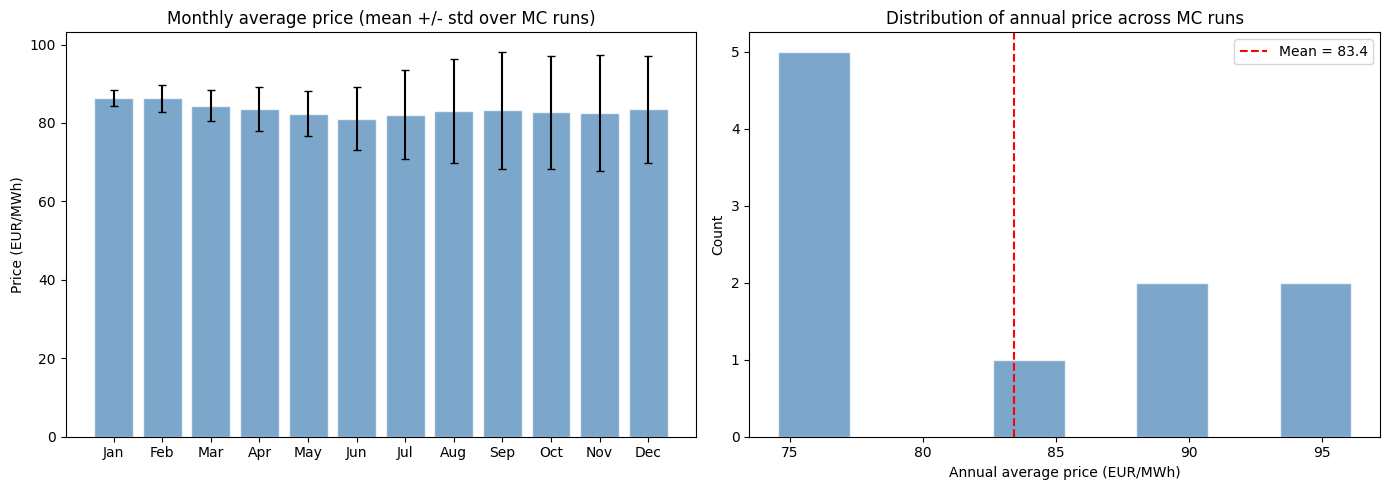

In [3]:
# Monthly price variation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Monthly prices across runs
ax = axes[0]
mean_monthly = mc.monthly_prices.mean(axis=0)
std_monthly = mc.monthly_prices.std(axis=0)
x = np.arange(12)
ax.bar(x, mean_monthly, yerr=std_monthly, color='steelblue', alpha=0.7,
       capsize=3, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.set_ylabel('Price (EUR/MWh)')
ax.set_title('Monthly average price (mean +/- std over MC runs)')

# Per-run distribution
ax = axes[1]
ax.hist(mc.avg_price, bins=8, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(mc.avg_price.mean(), color='red', ls='--', label=f"Mean = {mc.avg_price.mean():.1f}")
ax.set_xlabel('Annual average price (EUR/MWh)')
ax.set_ylabel('Count')
ax.set_title('Distribution of annual price across MC runs')
ax.legend()

plt.tight_layout()
plt.show()

## 2. Technology Sensitivity Sweep

`sweep_technology()` varies one technology from 0% to N% of total installed capacity and collects price/emissions/inertia. Let's sweep nuclear penetration:

In [4]:
# Nuclear sweep (0-25%, 6 points, 10 runs each for speed)
nuc_results = sweep_technology(
    ITALIAN_MIX, 'nuclear',
    np.array([0, 5, 10, 15, 20, 25]),
    GAS_SCENARIOS['base'],
    n_runs=10, seed=42,
)

  nuclear 0%: price=83.42 EUR/MWh, H=4.35s, CO₂=73.80 Mt, CI=217 gCO₂/kWh
  nuclear 5%: price=82.42 EUR/MWh, H=4.48s, CO₂=61.00 Mt, CI=179 gCO₂/kWh
  nuclear 10%: price=80.05 EUR/MWh, H=4.61s, CO₂=48.39 Mt, CI=142 gCO₂/kWh
  nuclear 15%: price=75.17 EUR/MWh, H=4.74s, CO₂=36.38 Mt, CI=107 gCO₂/kWh
  nuclear 20%: price=66.08 EUR/MWh, H=4.90s, CO₂=25.61 Mt, CI=75 gCO₂/kWh
  nuclear 25%: price=53.58 EUR/MWh, H=5.07s, CO₂=16.86 Mt, CI=50 gCO₂/kWh


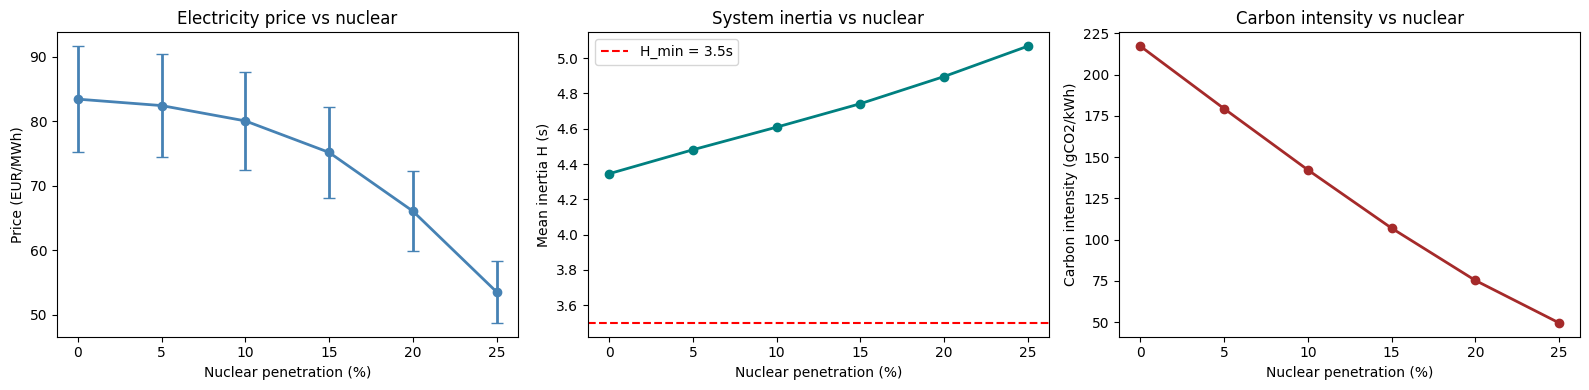

In [5]:
pcts = [r['pct'] for r in nuc_results]
prices = [r['mean_price'] for r in nuc_results]
stds = [r['std_price'] for r in nuc_results]
inertias = [r['mean_inertia'] for r in nuc_results]
ci = [r['mean_carbon_intensity'] for r in nuc_results]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Price
axes[0].errorbar(pcts, prices, yerr=stds, fmt='o-', color='steelblue',
                 capsize=4, lw=2)
axes[0].set_xlabel('Nuclear penetration (%)')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Electricity price vs nuclear')

# Inertia
axes[1].plot(pcts, inertias, 'o-', color='teal', lw=2)
axes[1].axhline(3.5, color='red', ls='--', label='H_min = 3.5s')
axes[1].set_xlabel('Nuclear penetration (%)')
axes[1].set_ylabel('Mean inertia H (s)')
axes[1].set_title('System inertia vs nuclear')
axes[1].legend()

# Carbon intensity
axes[2].plot(pcts, ci, 'o-', color='brown', lw=2)
axes[2].set_xlabel('Nuclear penetration (%)')
axes[2].set_ylabel('Carbon intensity (gCO2/kWh)')
axes[2].set_title('Carbon intensity vs nuclear')

plt.tight_layout()
plt.show()

## 3. Solar sweep — the price cannibalization effect

Adding solar has diminishing returns: as penetration rises, solar increasingly competes with itself (all solar generates at the same hours), driving midday prices to zero:

In [6]:
solar_results = sweep_technology(
    ITALIAN_MIX, 'solar',
    np.array([0, 10, 20, 30, 40]),
    GAS_SCENARIOS['base'],
    n_runs=10, seed=42,
)

  solar 0%: price=83.62 EUR/MWh, H=4.35s, CO₂=85.54 Mt, CI=253 gCO₂/kWh
  solar 10%: price=83.63 EUR/MWh, H=4.35s, CO₂=81.95 Mt, CI=241 gCO₂/kWh
  solar 20%: price=83.60 EUR/MWh, H=4.35s, CO₂=78.11 Mt, CI=230 gCO₂/kWh
  solar 30%: price=83.46 EUR/MWh, H=4.35s, CO₂=74.28 Mt, CI=219 gCO₂/kWh
  solar 40%: price=82.71 EUR/MWh, H=4.34s, CO₂=70.54 Mt, CI=208 gCO₂/kWh


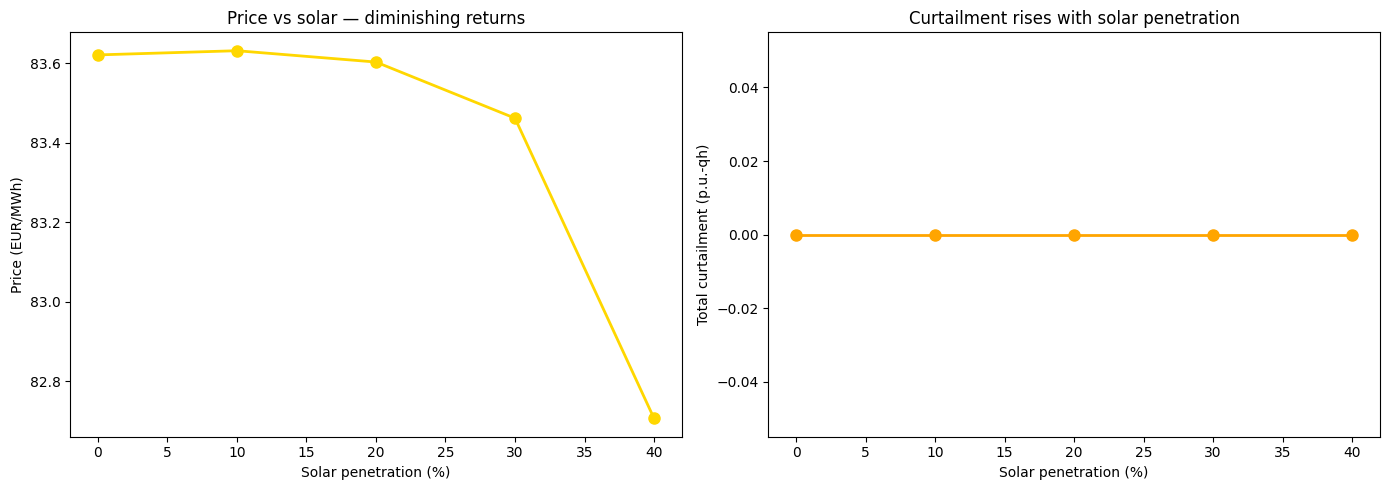

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

s_pcts = [r['pct'] for r in solar_results]
s_prices = [r['mean_price'] for r in solar_results]
s_curtail = [r['mean_curtailment'] for r in solar_results]

axes[0].plot(s_pcts, s_prices, 'o-', color='gold', lw=2, ms=8)
axes[0].set_xlabel('Solar penetration (%)')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Price vs solar — diminishing returns')

axes[1].plot(s_pcts, s_curtail, 'o-', color='orange', lw=2, ms=8)
axes[1].set_xlabel('Solar penetration (%)')
axes[1].set_ylabel('Total curtailment (p.u.-qh)')
axes[1].set_title('Curtailment rises with solar penetration')

plt.tight_layout()
plt.show()

## 4. 2D Heatmap: Technology × Gas Scenario

How does the value of nuclear change under different gas price regimes?

In [8]:
price_mat, inertia_mat, gas_labels = build_sensitivity_heatmap(
    ITALIAN_MIX, 'nuclear',
    GAS_SCENARIOS,
    np.array([0, 10, 20]),
    n_runs=10, seed=42,
)


── Gas scenario: base (μ=35 EUR/MWh) ──
  nuclear 0%: price=83.42 EUR/MWh, H=4.35s, CO₂=73.80 Mt, CI=217 gCO₂/kWh
  nuclear 10%: price=80.05 EUR/MWh, H=4.61s, CO₂=48.39 Mt, CI=142 gCO₂/kWh
  nuclear 20%: price=66.08 EUR/MWh, H=4.90s, CO₂=25.61 Mt, CI=75 gCO₂/kWh

── Gas scenario: tension (μ=55 EUR/MWh) ──
  nuclear 0%: price=115.63 EUR/MWh, H=4.35s, CO₂=73.80 Mt, CI=217 gCO₂/kWh
  nuclear 10%: price=110.72 EUR/MWh, H=4.61s, CO₂=48.39 Mt, CI=142 gCO₂/kWh
  nuclear 20%: price=90.48 EUR/MWh, H=4.90s, CO₂=25.61 Mt, CI=75 gCO₂/kWh

── Gas scenario: crisis (μ=90 EUR/MWh) ──
  nuclear 0%: price=172.68 EUR/MWh, H=4.35s, CO₂=73.80 Mt, CI=217 gCO₂/kWh
  nuclear 10%: price=165.07 EUR/MWh, H=4.61s, CO₂=48.39 Mt, CI=142 gCO₂/kWh
  nuclear 20%: price=133.73 EUR/MWh, H=4.90s, CO₂=25.61 Mt, CI=75 gCO₂/kWh


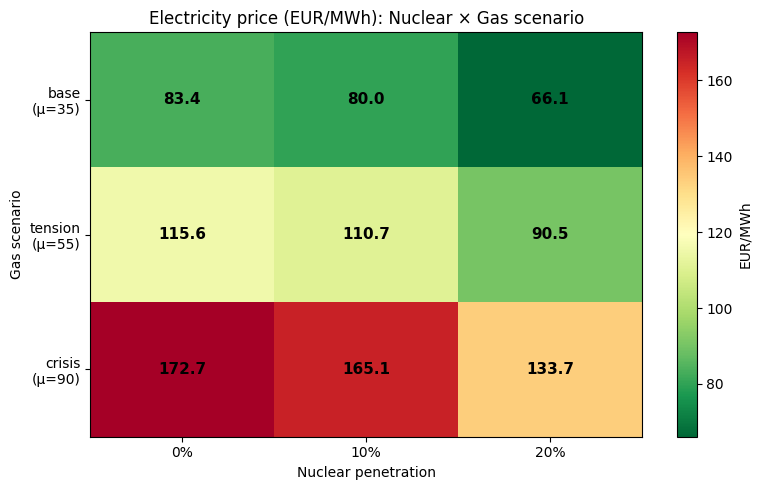

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(price_mat, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(price_mat.shape[1]))
ax.set_xticklabels(['0%', '10%', '20%'])
ax.set_yticks(range(len(gas_labels)))
ax.set_yticklabels(gas_labels)
ax.set_xlabel('Nuclear penetration')
ax.set_ylabel('Gas scenario')
ax.set_title('Electricity price (EUR/MWh): Nuclear × Gas scenario')

# Annotate cells
for i in range(price_mat.shape[0]):
    for j in range(price_mat.shape[1]):
        ax.text(j, i, f'{price_mat[i, j]:.1f}', ha='center', va='center',
                fontsize=11, fontweight='bold')

plt.colorbar(im, ax=ax, label='EUR/MWh')
plt.tight_layout()
plt.show()

## 5. Incremental Heatmap: Marginal Value

The incremental heatmap shows the **marginal price impact** of adding a small increment of capacity at different base penetrations. This reveals **diminishing returns** and **non-linearities**:

In [10]:
delta_price, marginal_cost = build_incremental_heatmap(
    ITALIAN_MIX, 'nuclear',
    base_penetrations_pct=np.array([0, 5, 10, 15, 20]),
    increments_pct=np.array([2, 5, 10]),
    gas_scenario=GAS_SCENARIOS['base'],
    n_runs=10, seed=42,
)


── Incremental heatmap for nuclear: 12 unique penetration levels ──
  nuclear 0%: price=83.42 EUR/MWh, H=4.35s, CO₂=73.80 Mt, CI=217 gCO₂/kWh
  nuclear 2%: price=83.14 EUR/MWh, H=4.40s, CO₂=68.68 Mt, CI=202 gCO₂/kWh
  nuclear 5%: price=82.42 EUR/MWh, H=4.48s, CO₂=61.00 Mt, CI=179 gCO₂/kWh
  nuclear 7%: price=81.64 EUR/MWh, H=4.53s, CO₂=55.91 Mt, CI=164 gCO₂/kWh
  nuclear 10%: price=80.05 EUR/MWh, H=4.61s, CO₂=48.39 Mt, CI=142 gCO₂/kWh
  nuclear 12%: price=78.54 EUR/MWh, H=4.66s, CO₂=43.48 Mt, CI=128 gCO₂/kWh
  nuclear 15%: price=75.17 EUR/MWh, H=4.74s, CO₂=36.38 Mt, CI=107 gCO₂/kWh
  nuclear 17%: price=72.14 EUR/MWh, H=4.80s, CO₂=31.88 Mt, CI=94 gCO₂/kWh
  nuclear 20%: price=66.08 EUR/MWh, H=4.90s, CO₂=25.61 Mt, CI=75 gCO₂/kWh
  nuclear 22%: price=61.22 EUR/MWh, H=4.96s, CO₂=21.84 Mt, CI=64 gCO₂/kWh
  nuclear 25%: price=53.58 EUR/MWh, H=5.07s, CO₂=16.86 Mt, CI=50 gCO₂/kWh
  nuclear 30%: price=42.29 EUR/MWh, H=5.22s, CO₂=10.30 Mt, CI=30 gCO₂/kWh


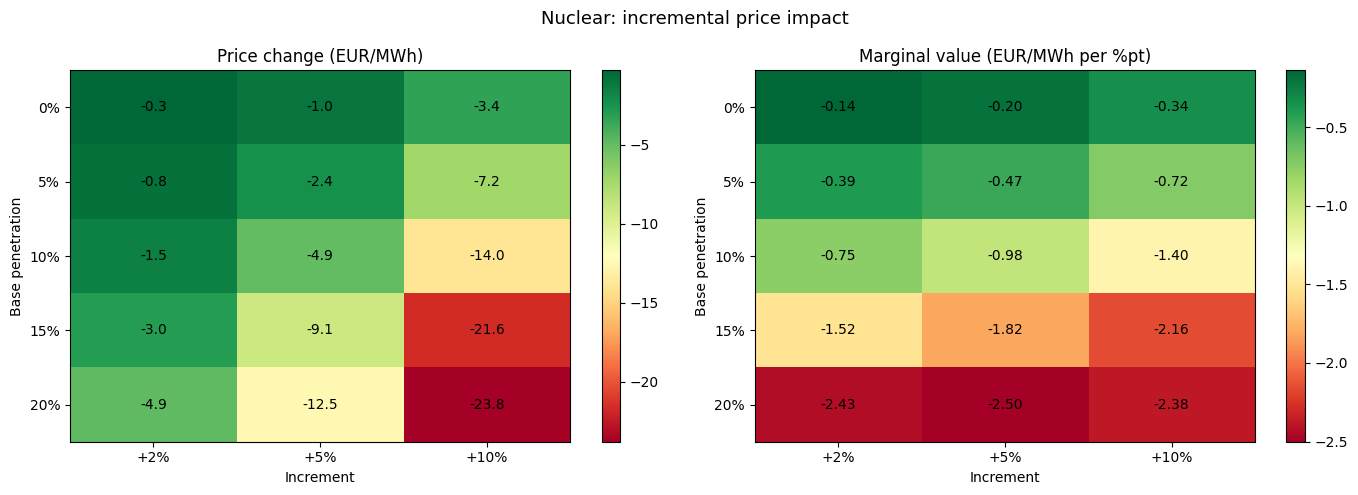

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

base_pcts = [0, 5, 10, 15, 20]
inc_pcts = [2, 5, 10]

# Delta price
im0 = axes[0].imshow(delta_price, cmap='RdYlGn', aspect='auto')
axes[0].set_xticks(range(len(inc_pcts)))
axes[0].set_xticklabels([f'+{d}%' for d in inc_pcts])
axes[0].set_yticks(range(len(base_pcts)))
axes[0].set_yticklabels([f'{b}%' for b in base_pcts])
axes[0].set_xlabel('Increment')
axes[0].set_ylabel('Base penetration')
axes[0].set_title('Price change (EUR/MWh)')
for i in range(len(base_pcts)):
    for j in range(len(inc_pcts)):
        axes[0].text(j, i, f'{delta_price[i,j]:+.1f}', ha='center', va='center', fontsize=10)
plt.colorbar(im0, ax=axes[0])

# Marginal cost per %
im1 = axes[1].imshow(marginal_cost, cmap='RdYlGn', aspect='auto')
axes[1].set_xticks(range(len(inc_pcts)))
axes[1].set_xticklabels([f'+{d}%' for d in inc_pcts])
axes[1].set_yticks(range(len(base_pcts)))
axes[1].set_yticklabels([f'{b}%' for b in base_pcts])
axes[1].set_xlabel('Increment')
axes[1].set_ylabel('Base penetration')
axes[1].set_title('Marginal value (EUR/MWh per %pt)')
for i in range(len(base_pcts)):
    for j in range(len(inc_pcts)):
        axes[1].text(j, i, f'{marginal_cost[i,j]:+.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im1, ax=axes[1])

plt.suptitle('Nuclear: incremental price impact', fontsize=13)
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Monte Carlo** converts a single dispatch into a **distribution** — you get means, standard deviations, and confidence intervals.
2. **Seed management** (base_seed + run_index) makes everything reproducible.
3. **Technology sweeps** reveal diminishing returns: the first 10% of nuclear has a larger price impact than the next 10%.
4. **Solar cannibalization**: beyond ~30% penetration, solar drives its own price to zero during peak hours, reducing its value per additional GW.
5. **2D heatmaps** show that technology value depends on the fuel price regime: nuclear is most valuable during a gas crisis.
6. **Incremental analysis** quantifies the marginal EUR/MWh benefit of each additional percentage point, capturing non-linearity that simple averages miss.

**Next notebook**: [07 — Fuel Price Sensitivity](./07_fuel_price_sensitivity.ipynb) — how exposed is the electricity price to fuel shocks?